<a href="https://www.kaggle.com/code/erikanderson1/bbc-news-classification-using-matrix-factorization?scriptVersionId=233863373" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Classifying article topics with matrix factorization
In our information age, a vast amount of text is produced every day. Classifying text based solely on the information it contains can help make relevant information easier to find. 

Text classification is a task within the machine learning domain of Natural Language Processing (NLP). Both supervised and unsupervised  methods are available for this task. These systems can be used to support information discovery, filter relevant information, and organize information for later retrieval. 

This notebook compares an unsupervised approach, matrix factorization, with supervised approaches to accurately classify previously unseen news articles using accuracy as a metric.

In [1]:
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics import make_scorer, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/learn-ai-bbc/BBC News Train.csv
/kaggle/input/learn-ai-bbc/BBC News Sample Solution.csv
/kaggle/input/learn-ai-bbc/BBC News Test.csv


# Exploratory Data Analysis (EDA)
## Data
Kaggle provides a dataset from the BBC of 2,225 articles labeled with one of five categories: business, entertainment, politics, sports, or technology (tech). 735 records are reserved in the public test set leaving 1,490 records for training.

In [2]:
data = pd.read_csv('/kaggle/input/learn-ai-bbc/BBC News Train.csv')
data.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [3]:
data.loc[0, "Text"]

'worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practices used by worldcom. mr ebb

There are no null values in the training dataset. 100 duplicate records are removed from the training dataset.

In [4]:
data.isna().sum()

ArticleId    0
Text         0
Category     0
dtype: int64

In [5]:
data.duplicated(subset=['Text'], keep=False).sum()

100

In [6]:
data = data.drop_duplicates(subset=['Text'])
data.duplicated(subset=['Text'], keep=False).sum()

0

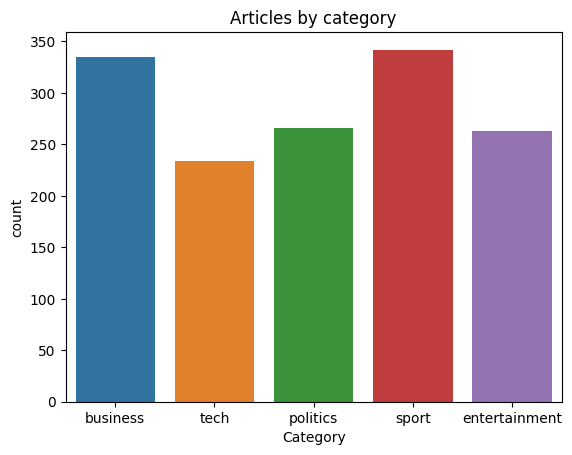

In [7]:
sns.countplot(data=data, x="Category")
plt.title("Articles by category");

The number of articles in each class is relatively balanced.

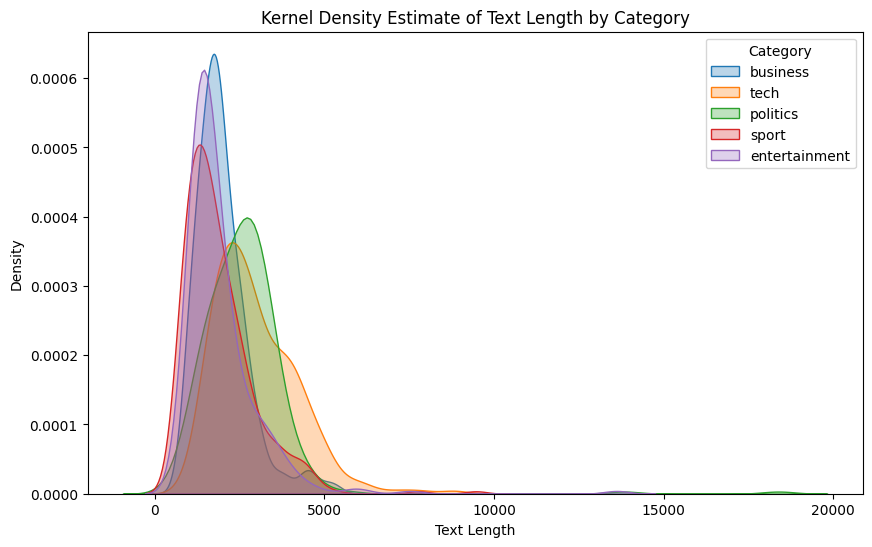

In [8]:
data["Text_Length"] = data["Text"].apply(len)

plt.figure(figsize=(10, 6))

for category in data["Category"].unique():
    subset = data[data["Category"] == category]
    sns.kdeplot(subset["Text_Length"], label=category, fill=True, alpha=0.3)

plt.xlabel("Text Length")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of Text Length by Category")
plt.legend(title="Category")
plt.show();

Article lengths are also fairly well matched, althrough politics includes a number of very long outliers.

# Analysis
## Pre-processing
For NLP tasks, pre-processing of the text is crucial. Pre-processing includes stemming (the conversion of words to their root form) and stop word removal (excluding common but low-value words such as "the").

I'll use the library `spacy` to manage the pre-processing pipeline. Based on the EDA above, I can keep the pipeline very simple by
1. converting each string of text to a document
2. extracting the root word
3. dropping stop words, punctuation and spaces

Once the text has been simplified in this way, I will vectorize using TF-IDF (Term Frequency-Inverse Document Frequency) which weights each word in a document based on its relative frequency, a proxy for the importance of a word, using the `sklearn` implementation `TfidfVectorizer`.

## Use of full dataset
In the case of exploratory topic modeling, which might be done to understand the number of and types of topics in a dataset like this, it is reasonable to use the full dataset (training and test datasets together). However, because my task includes evaluation of the model and comparison to supervised approaches, I will not use the full dataset to train the unsupervised model. Doing so could result in some leakage from the test dataset to the training dataset, and may lead to overfitting of the test dataset. While that might improve my accuracy scores for this competition, in the real world I would be predicting on unseen data and so could not use the data to fit my model.  

However, it is critical to apply the same TF-IDF vectorizer to the test set as the training set (e.g., use `fit` on the training set and then `transform` only on the test dataset).

In [9]:
nlp = spacy.load("en_core_web_sm")
docs = list(nlp.pipe(data["Text"], 
                     disable=[
                         "tok2vec", "tagger", "parser", 
                         "attribute_ruler", "ner"])
           )

/usr/local/lib/python3.10/dist-packages/spacy/pipeline/lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [10]:
def stem_text(doc):
    text = ' '.join([token.lemma_ for token in doc 
                     if not token.is_stop 
                     and not token.is_punct
                     and not token.is_space])
    return text

In [11]:
data["text_stem"] = [stem_text(doc) for doc in docs]
data.loc[0, "text_stem"]

'worldcom ex boss launches defence lawyers defending worldcom chief bernie ebbers battery fraud charges called company whistleblower witness cynthia cooper worldcom s ex head internal accounting alerted directors irregular accounting practices telecoms giant 2002 warnings led collapse firm following discovery $ 11bn £ 5.7bn accounting fraud mr ebbers pleaded guilty charges fraud conspiracy prosecution lawyers argued mr ebbers orchestrated series accounting tricks worldcom ordering employees hide expenses inflate revenues meet wall street earnings estimates ms cooper runs consulting business told jury new york wednesday external auditors arthur andersen approved worldcom s accounting early 2001 2002 said andersen given green light procedures practices worldcom mr ebber s lawyers said unaware fraud arguing auditors alert problems ms cooper said shareholder meetings mr ebbers passed technical questions company s finance chief giving brief answers prosecution s star witness worldcom financ

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(data['text_stem'])

print(X_tfidf.shape)

(1440, 5000)


## Non-negative Matrix Factorization
Non-negative matrix factorization decomposes am $n \times m$ matrix into two components by finding a matrix $d$ where
$$m \times n = (m \times d) \times (d \times n)$$

Each row of the first factorized matrix $m \times d$ represents a document’s association with each topic, while each column of the second factorized matrix $d \times n$ represents how strongly each word contributes to a given topic.

In the context of document classification, the matrix $d$ can be interpreted as capturing the semantic structure of the documents and 
enables classification by associating documents with the most relevant topics based on their composition of words.

In this way, Non-negative Matrix factorization provides a dimensionality reduction of the original matrix `X_tfidf` to one with $5$ rather than $5000$ columns. 

In [13]:
n_topics = len(data['Category'].unique())
nmf = NMF(n_components=n_topics, random_state=42)
X_nmf = nmf.fit_transform(X_tfidf)

print(X_nmf.shape)

(1440, 5)


Interrogating the first column we can see the weighting for each topic. The first article is correctly classified as 'business' because the weight is greatest for that element.

In [14]:
X_nmf[0,:]

array([0.00056279, 0.04234842, 0.0450577 , 0.00364387, 0.009259  ])

Let's store the output in the data table and assign human-readable labels so we can compare and calculate the accuracy of our model.

In [15]:
data["predicted"] = X_nmf.argmax(axis=1)
data.head()

,ArticleId,Text,Category,Text_Length,text_stem,predicted
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866,worldcom ex boss launches defence lawyers defe...,2
1,154,german business confidence slides german busin...,business,2016,german business confidence slides german busin...,2
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104,bbc poll indicates economic gloom citizens maj...,2
3,1976,lifestyle governs mobile choice faster bett...,tech,3618,lifestyle governs mobile choice faster better ...,4
4,917,enron bosses in $168m payout eighteen former e...,business,2190,enron bosses $ 168 m payout eighteen enron dir...,2


In [16]:
def get_labels(y_true, y_pred):
    topic_mapping = {}
    y_true = np.array(y_true)

    for topic in np.unique(y_pred):
        indices = np.where(y_pred == topic)[0]
        topic_docs_labels = y_true[indices] if len(indices) > 0 else []

        if len(topic_docs_labels) > 0:
            most_common_label = Counter(topic_docs_labels).most_common(1)[0][0]
            topic_mapping[topic] = most_common_label
        else:
            topic_mapping[topic] = -1  # -1 represents "Unknown" category

    return topic_mapping

topic_mapping = get_labels(data['Category'], data['predicted'])
topic_mapping

{0: 'sport', 1: 'politics', 2: 'business', 3: 'entertainment', 4: 'tech'}

In [17]:
topic_mapping = get_labels(data['Category'], data['predicted'])
topic_mapping

{0: 'sport', 1: 'politics', 2: 'business', 3: 'entertainment', 4: 'tech'}

In [18]:
data["predicted_label"] = data['predicted'].map(topic_mapping)
data.head()

,ArticleId,Text,Category,Text_Length,text_stem,predicted,predicted_label
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866,worldcom ex boss launches defence lawyers defe...,2,business
1,154,german business confidence slides german busin...,business,2016,german business confidence slides german busin...,2,business
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104,bbc poll indicates economic gloom citizens maj...,2,business
3,1976,lifestyle governs mobile choice faster bett...,tech,3618,lifestyle governs mobile choice faster better ...,4,tech
4,917,enron bosses in $168m payout eighteen former e...,business,2190,enron bosses $ 168 m payout eighteen enron dir...,2,business


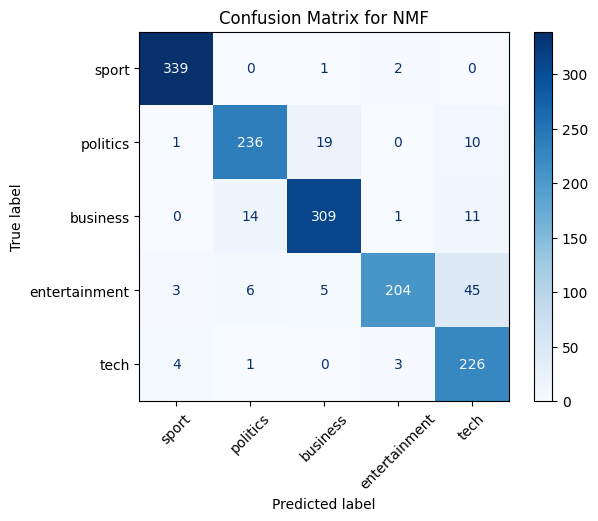

In [19]:
cm = confusion_matrix(data["Category"], data["predicted_label"], labels=list(topic_mapping.values()))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(topic_mapping.values()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for NMF")
plt.show()

In [20]:
print(f'Accuracy: {accuracy_score(data["Category"], data["predicted_label"]):.2%}')

Accuracy: 91.25%


### Performance on Test Dataset
To evaluate performance on the test dataset (which does not include labels), I'll export a csv and submit to Kaggle to get the results from the public leaderboard.

In [21]:
test_df = pd.read_csv('/kaggle/input/learn-ai-bbc/BBC News Test.csv')
test_docs = list(nlp.pipe(test_df["Text"], 
                     disable=[
                         "tok2vec", "tagger", "parser", 
                         "attribute_ruler", "ner"])
           )
test_df["text_stem"] = [stem_text(doc) for doc in test_docs]
test_tfidf = vectorizer.transform(test_df['text_stem'])

/usr/local/lib/python3.10/dist-packages/spacy/pipeline/lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [22]:
test_pred = nmf.transform(test_tfidf).argmax(axis=1)
test_pred_labels = np.array([topic_mapping.get(t, "Unknown") for t in test_pred])
submission = pd.DataFrame({
    'ArticleId': test_df['ArticleId'],
    'Category': test_pred_labels
})
submission.to_csv('submission_nmf_defaults.csv', index=False)

After submission, the test accuracy of the NMF with default parameters is 92.517%

## Hyperparameter Tuning
Next I'll use a `GridSearchCV` strategy to tune the hyperparameters of the `NMF` model to improve the accuracy. 

In [23]:
y_true = data['Category']

In [24]:
# Custom scoring function for classifier
def nmf_accuracy(model, X, y_true):
    """Computes accuracy based on best topic-to-category mapping."""
    X_topics = model.transform(X)
    y_pred = X_topics.argmax(axis=1)

    topic_mapping = get_labels(y_true, y_pred)
    
    y_pred_labels = np.array([topic_mapping.get(t, "Unknown") for t in y_pred])

    return accuracy_score(y_true, y_pred_labels)

In [25]:
# Define the NMF model
nmf = NMF(random_state=42, max_iter=100)  # Adjust max_iter for stability

# Define the parameter grid
param_grid = {
    'nmf__n_components': [5],
    'nmf__alpha_W': [0.0, 0.1, 0.5],
    'nmf__alpha_H': [0.0, 0.1, 0.5],
    'nmf__l1_ratio': [0.0, 0.5, 1.0],
    'nmf__solver': ['cd', 'mu']
}

# Define the pipeline
pipeline = Pipeline([
    ('nmf', nmf)
])

# Perform Grid Search with accuracy scoring
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=nmf_accuracy,
    cv=3,
    verbose=2,
    n_jobs=-1  # Use all CPU cores
)

# Fit GridSearchCV on the TF-IDF matrix
grid_search.fit(X_tfidf, y_true)

# Get the best parameters
print("Best Parameters:", grid_search.best_params_)

# Get the best model
best_nmf = grid_search.best_estimator_


Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [0.88819444 0.89583333 0.88819444 0.89583333 0.88819444 0.89583333
 0.89513889 0.89861111 0.24166667 0.91597222 0.24166667 0.91666667
 0.89305556 0.90069444 0.24166667 0.91597222 0.24166667 0.91666667
 0.89652778 0.89861111        nan 0.8125            nan 0.79236111
 0.24166667 0.24166667        nan        nan 0.24166667        nan
 0.24166667 0.24166667        nan        nan 0.24166667        nan
 0.89652778 0.89861111        nan 0.81041667        nan 0.79097222
 0.24166667 0.24166667        nan        nan 0.24166667        nan
 0.24166667 0.24166667        nan        nan 0.24166667        nan]
  warnings.warn(


Best Parameters: {'nmf__alpha_H': 0.0, 'nmf__alpha_W': 0.1, 'nmf__l1_ratio': 1.0, 'nmf__n_components': 5, 'nmf__solver': 'mu'}


In [26]:
print(f"Best Accuracy: {nmf_accuracy(best_nmf, X_tfidf, y_true):.2%}")

Best Accuracy: 91.94%


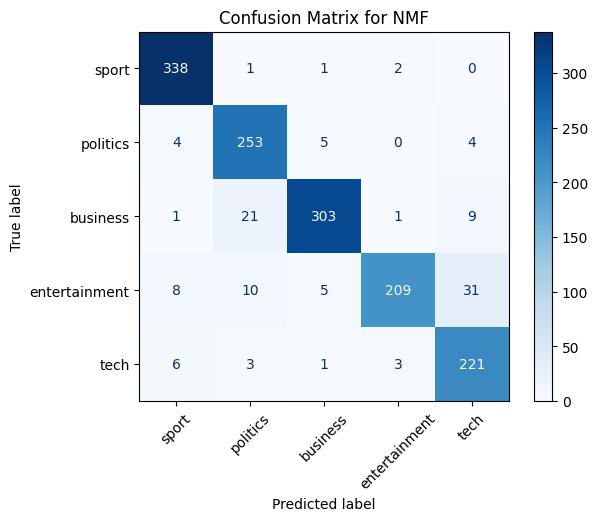

In [27]:
# Get labels for best model
X_topics = best_nmf.transform(X_tfidf)
y_pred = X_topics.argmax(axis=1)
topic_mapping = get_labels(y_true, y_pred)
y_pred_labels = np.array([topic_mapping.get(t, "Unknown") for t in y_pred])

cm = confusion_matrix(y_true, y_pred_labels, labels=list(topic_mapping.values()))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(topic_mapping.values()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for NMF")
plt.show()

### Test set accuracy

In [28]:
test_pred = best_nmf.transform(test_tfidf).argmax(axis=1)
test_pred_labels = np.array([topic_mapping.get(t, "Unknown") for t in test_pred])
submission = pd.DataFrame({
    'ArticleId': test_df['ArticleId'],
    'Category': test_pred_labels
})
submission.to_csv('submission_nmf_tuned.csv', index=False)

The test set accuracy decreased to 92.24% from 92.52% after hyperparameter tuning, althought the training set accuracy increased slightly from 91.25% to 91.94%. This indicates the model overfit slightly to the training data during hyperparameter tuning.

## Supervised Approach: Historgram-Based Gradient Boosting
Next I'll compare the supervised learning approach Historgram-Based Gradient Boosting (a type of gradient boosting method inspired by LightGBM).

In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier
import time

X = data["text_stem"]
y = data["Category"]

for pct in [0.1, 0.2, 0.5, 0.7, 0.9]:
    start_time = time.time()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=1 - pct, random_state=42)
    
    X_tfidf_train = vectorizer.transform(X_train)
    
    hgbc = HistGradientBoostingClassifier(max_iter=100)
    hgbc = hgbc.fit(X_tfidf_train.toarray(), y_train)

    X_tfidf_test = vectorizer.transform(X_test)
    accuracy = hgbc.score(X_tfidf_test.toarray(), y_test)
    
    end_time = time.time()
    execution_time = (end_time - start_time)

    print(f'Accuracy of {accuracy:.2%} for {pct:.0%} of the data in training set. Execution Time: {execution_time:.2f}s')

Accuracy of 64.97% for 10% of the data in training set. Execution Time: 21.56s
Accuracy of 86.46% for 20% of the data in training set. Execution Time: 42.08s
Accuracy of 93.61% for 50% of the data in training set. Execution Time: 93.59s
Accuracy of 94.46% for 70% of the data in training set. Execution Time: 101.74s
Accuracy of 93.06% for 90% of the data in training set. Execution Time: 105.06s


The accuracy of the HBGB model increases as more data are included in the training data, up to a point of about 70% where it plateaus and then decreases, suggesting overfitting on the training data. Execution time increases in near linear time with the amount of data in the training set.

To better understand overfitting better, each of the test sets could be submitted to Kaggle. I expect that at the higher ends of the proportion of data included in the training set, overfitting is increasingly likely, and performance on the public test set will decrease.

In [30]:
test_pred_labels = hgbc.predict(test_tfidf.toarray())
submission = pd.DataFrame({
    'ArticleId': test_df['ArticleId'],
    'Category': test_pred_labels
})
submission.to_csv('submission_hgbc.csv', index=False)

The accuracy on the test set for HGBC is 94.693%, somewhat better than non-negative matrix factorization.

# Conclusion
In this notebook, I compared Non-negative Matrix Factorization (NMF), an unsupervised machine learning approach, to Histogram Based Gradient Boosting (HBGB), a supervised approach, to predict topics of news articles in one of five categories: entertainment, sports, tech, politics, and business. 

Both methods provided fairly high accuracy of 90-95% on both the provided data and the public test set. HBGB performed slightly higher than NMF. Further improvements could be made with additional hyperparameter tuning, ensembling, adjusting the pre-processing and vectorization approaches, and potentially including alternative machine learning approaches.